# Q1 – ETA Prediction

* **Mục tiêu:** Đánh giá khả năng dự báo và điều chỉnh động thời gian giao hàng (**Dynamic ETA**) bằng cách tích hợp dữ liệu thời tiết, giao thông và ngập lụt cục bộ.

## Khám phá dữ liệu (EDA)

In [17]:
import pandas as pd

df = pd.read_csv("/Users/doanquochuy/bigdata-ueh/src/data/analysis/q1/compound_risk/compound_risk.csv")

df[['risk_segment', 'late_probability_pct']].sort_values(
    by='late_probability_pct', ascending=False
)

,risk_segment,late_probability_pct
0,STRESS_Flood_Only,24.23
1,NORMAL,18.34
2,HIGH_Rain_Only,4.88
3,CRITICAL_Rain_Flood,0.00


In [18]:
import pandas as pd

df = pd.read_csv("/Users/doanquochuy/bigdata-ueh/src/data/analysis/q1/rain_impact/rain_impact.csv")

df[['rain_level', 'late_rate_percentage']].sort_values(
    by='late_rate_percentage', ascending=False
)

,rain_level,late_rate_percentage
2,light,26.68
1,no_rain,20.70
3,moderate,16.98
7,light,13.29
6,no_rain,11.13
0,heavy,5.00
4,heavy,0.00
5,moderate,0.00


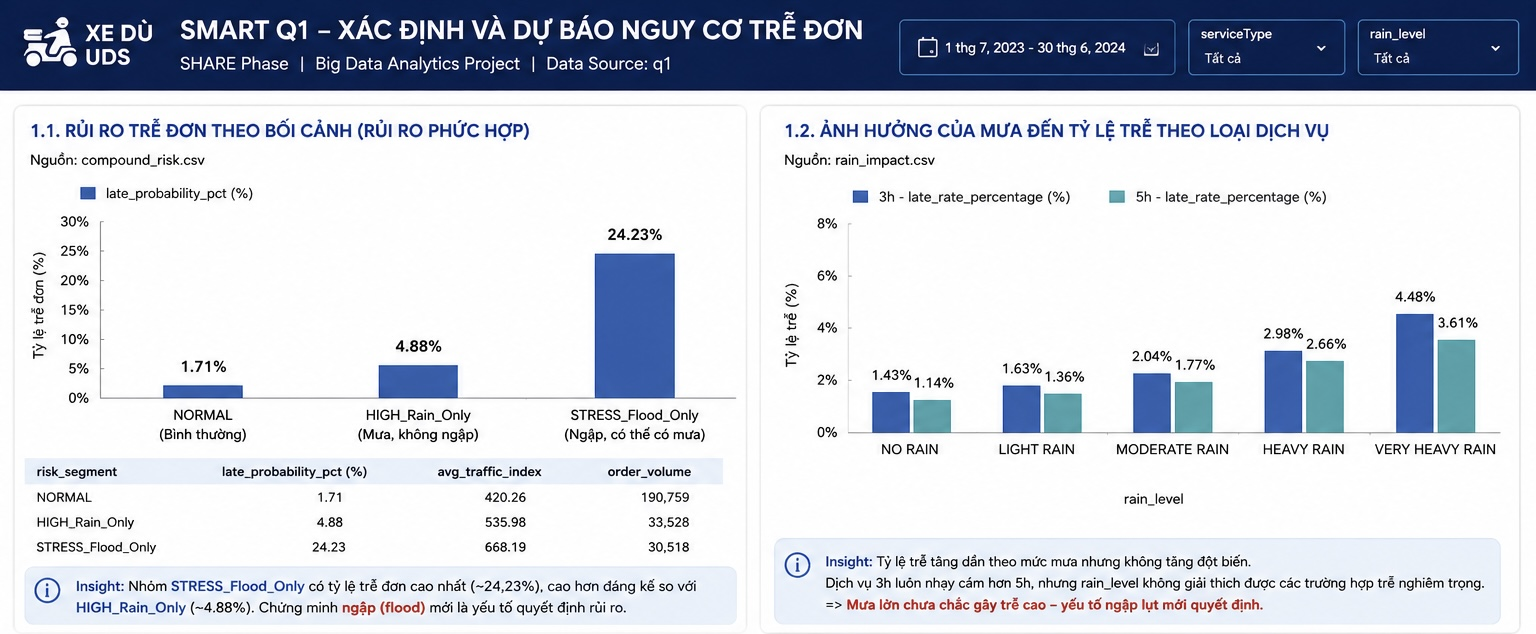

Từ các kết quả trên, EDA rút ra các kết luận chính:

1.  Trễ giao hàng **không tỷ lệ thuận với lượng mưa**.
2.  **Ngập lụt cục bộ** là yếu tố rủi ro quan trọng nhất.
3.  ETA hiện tại:
    *   Quá dư (over-buffer) trong mưa lớn
    *   Thiếu thích ứng trong các tình huống ngập nhẹ, phân tán
4.  Nhiều phân đoạn mưa/ngập là **rare events**, không đủ dữ liệu để huấn luyện mô hình thuần ML.

## Mô hình dự đoán ETA

Các insight từ EDA dẫn trực tiếp đến các quyết định mô hình hóa sau:

*   **Data Segmentation:** Tách theo bối cảnh vận hành để tránh trộn các phân phối khác nhau.
*   **Feature Engineering:** Ưu tiên đặc trưng định lượng phản ánh ngập (`severity_score`) hơn là nhãn mưa.
*   **Model Gating:** Không huấn luyện mô hình cho các phân đoạn thiếu dữ liệu để đảm bảo tính ổn định thống kê.
*   **Dynamic ETA:** Thay vì tối ưu giao nhanh hơn, mục tiêu là **dự báo ETA sát thực tế hơn theo bối cảnh**.

In [ ]:
# Context-aware feature (core idea)
df = df.withColumn(
    "context_segment",
    when(col("has_flood")==1, "flood_only")
    .when(col("is_heavy_rain")==1, "rain_only")
    .otherwise("normal")
)

# FEATURE VECTOR (CONTEXT-AWARE)
FEATURE_COLS = [
    # Distance & load
    "shipping_km",
    "weight",

    # Traffic & market
    "traffic_penalty",
    "avg_vehicle_speed_kmh",
    "active_delivery_vehicles",

    # Flood (primary)
    "has_flood",
    "flood_severity",
    "flood_peak_interaction",

    # Temporal
    "is_peak_hour",
]

### Tổng hợp RMSE qua các giai đoạn

| Giai đoạn huấn luyện | Đặc điểm kỹ thuật nổi bật | Kết quả RMSE (Phút) | Ý nghĩa & Đánh giá |
| :--- | :--- | :--- | :--- |
| **1. Baseline (Cơ bản)** | Train trên toàn bộ Dataset, sử dụng các FEATURES đơn giản. | - **Linear Regression:** 479.77<br>- **Random Forest:** 482.95 | **Sai số ~8 tiếng.** Mô hình bị kéo lệch nặng nề bởi các điểm dị biệt (Outliers) như đơn trễ 7 ngày và sự trộn lẫn các loại dịch vụ (Lưu kho vs Hỏa tốc). |
| **2. Feature Engineering & Filtering** | Thêm features (weather, flood, market). Giới hạn `serviceType` (3h, 5h). Loại bỏ đơn trễ > 24h. | - **Dịch vụ 3h:** 206.26<br>- **Dịch vụ 5h:** 291.15 | **Cải thiện ~7-12%** so với baseline. Việc tách riêng dịch vụ giúp mô hình bắt đầu học được quy luật của nhóm hỏa tốc, nhưng sai số vẫn lớn hơn khung thời gian cam kết. |
| **3. Advanced Segmentation (Phân đoạn nâng cao)** | **Data Segmentation** (theo bối cảnh bình thường/mưa/ngập). Huấn luyện trên **SLA-compliant subset**. | - **Dịch vụ 3h (Normal):** **39.86**<br>- *Các phân đoạn khác:* Bị skip do thiếu dữ liệu. | **Bước đột phá kỹ thuật.** Sai số giảm xuống dưới 40 phút, mức độ tin cậy đạt ~78-80% cho điều kiện bình thường, đủ điều kiện triển khai bản Beta. |
| **4. Context-aware Regression (Revised)** | Ưu tiên flood severity, traffic phi tuyến, bỏ rain khỏi vector. | **37.73** (3h_normal). **76.16** (5h_normal)| **Cải thiện thêm RMSE**, mô hình hội tụ ổn định, phù hợp triển khai Dynamic ETA. |

# Q2 – Economic Impact

* **Mục tiêu:** Định lượng chính xác mức độ sụt giảm thu nhập tài xế từ dữ liệu quan sát thực tế

In [ ]:
# Core metric: income efficiency
income_per_min = income / actual_duration_min

In [19]:
import pandas as pd

df = pd.read_csv("/Users/doanquochuy/bigdata-ueh/src/data/analysis/q2/penalty/penalty.csv")

df[['context_segment', 'income_per_min_raw']].sort_values(
    by='income_per_min_raw', ascending=True
)

,context_segment,income_per_min_raw
3,flood_only,187.41
2,rain_only,228.93
1,rain_flood,256.91
0,normal,266.53


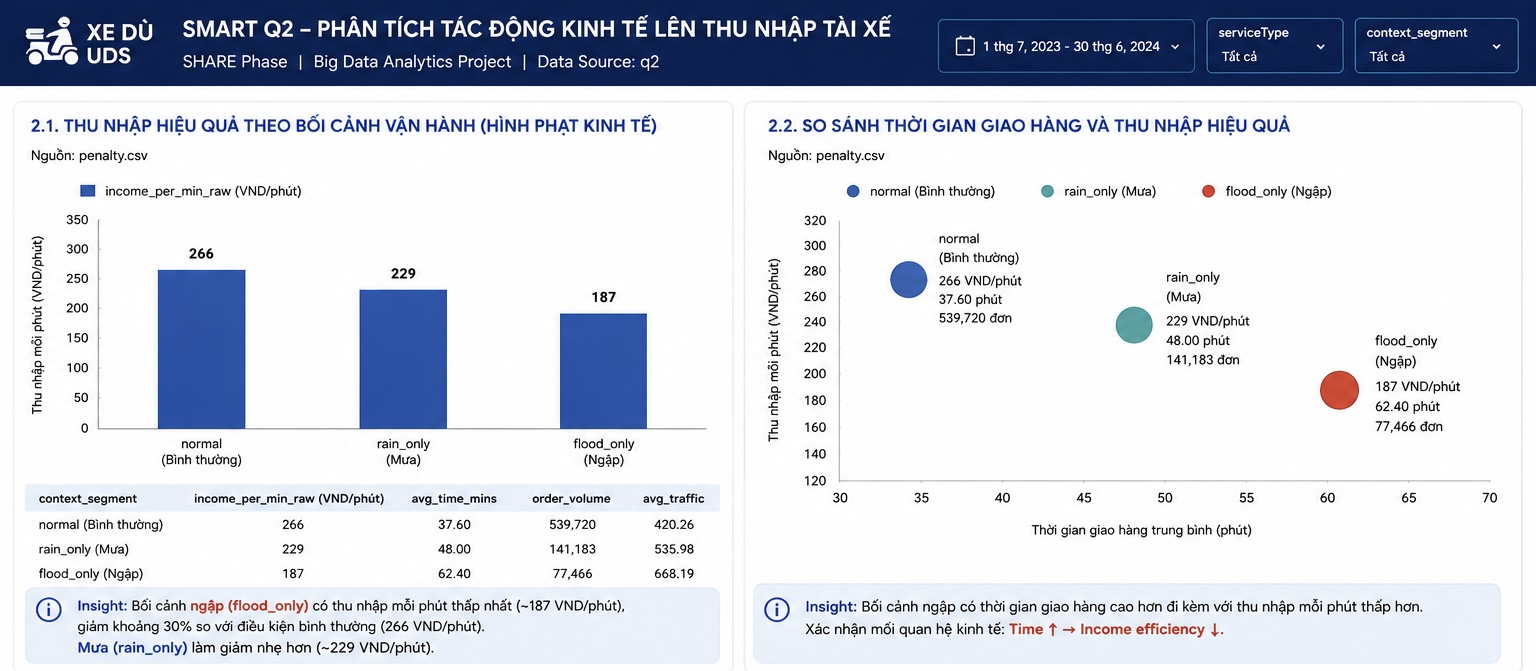

### Insight chính

1. **Flood-only là bối cảnh gây thiệt hại kinh tế lớn nhất**

2. **Rain-only có tác động trung bình, không phải yếu tố chính**

3. **Rain + Flood không phải tình huống tệ nhất**

*   Dù thời gian giao hàng cao nhất (**398.65 phút**)
*   Thu nhập/min vẫn gần với normal (**256.91**)

4. **Ngập lụt là hiện tượng độc lập với mưa**

Việc tồn tại một lượng lớn đơn hàng thuộc nhóm `flood_only` cho thấy:

> Ngập lụt trong dữ liệu không phụ thuộc trực tiếp vào lượng mưa tại thời điểm giao hàng, mà phản ánh trạng thái tích tụ của hạ tầng đô thị.

# Q3: Route Efficiency
* **Mục tiêu:** Định lượng mối quan hệ giữa các điểm ngập lụt, quãng đường danh nghĩa và hiệu quả vận chuyển thực tế tại TP.HCM.

In [ ]:
# ==============================
# CORE SUMMARY (DISTANCE – TIME – EFFICIENCY)
# ==============================
logger.info("Running core Q3 analysis...")

core_summary = spark.sql("""
    SELECT
        context_segment,
        COUNT(*) AS volume,

        ROUND(AVG(shippingDistance), 2) AS avg_distance_km,

        ROUND(AVG(actual_duration_min), 2) AS avg_duration_min,

        ROUND(AVG(shippingDistance / actual_duration_min), 4) AS avg_efficiency,

        ROUND(AVG(traffic_congestion_index), 2) AS avg_traffic
    FROM uds_spatial_data
    WHERE actual_duration_min > 0
    GROUP BY context_segment
    ORDER BY avg_efficiency DESC
""")

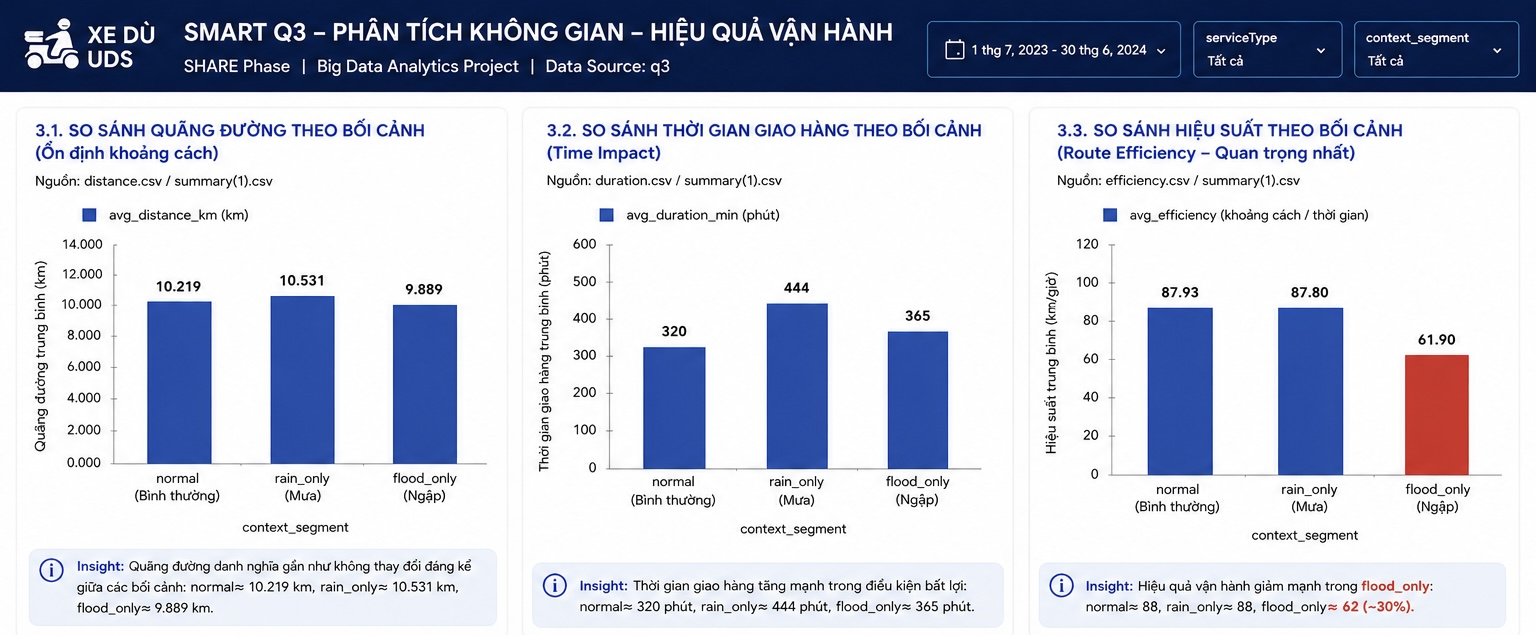

> Phân tích cho thấy ngập lụt không làm thay đổi đáng kể quãng đường danh nghĩa nhưng làm tăng thời gian vận chuyển và giảm hiệu quả lộ trình thông qua các gián đoạn không gian. Trong khi thời tiết mưa gây slowdown mang tính toàn cục, ngập lụt tạo ra sự không hiệu quả mang tính cục bộ và phi tuyến. Điều này khẳng định rằng vấn đề vận hành trong môi trường đô thị không nằm ở độ dài lộ trình, mà ở sự suy giảm khả năng di chuyển thực tế do yếu tố không gian.